# Análisis de afinidades SKU-SKU

Exploramos los patrones de co-ocurrencia y las métricas de afinidad (Jaccard) derivadas.
El objetivo es entender:

1. **Estructura del grafo:** distribución de scores, densidad, concentración.
2. **Sensibilidad a la métrica:** comparamos co-ocurrencia cruda vs Jaccard.
3. **Verificación de circularidad:** ¿la composición de batches correlaciona con zonas del layout actual? (sesgo potencial).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix
from abs_affinity_based_slotting.config import PROCESSED_DIR, RAW_DIR
from abs_affinity_based_slotting.data import read_parquet
from abs_affinity_based_slotting.demand import build_cooccurrence, affinity_registry

# Configuración de plots
#plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Cargar datos de entrenamiento


In [2]:
picking_train = read_parquet(PROCESSED_DIR / 'picking_train.parquet')
print(f"Picking train: {len(picking_train):,} líneas")
print(f"Batches: {picking_train['batch_id'].nunique():,}")
print(f"SKUs: {picking_train['sku'].nunique():,}")
print(f"\nPrimeras filas:")
picking_train.head()

Picking train: 139,632 líneas
Batches: 1,600
SKUs: 15,554

Primeras filas:


,batch_id,timestamp,user_id,location_id,location_name,bay_name,sku,merchant_account_id,quantity
0,BATCH-000001,2025-01-01 08:00:27.533333,064058,181,A01-07-A-01,A01-07,SKU-00169,MER-009,2
1,BATCH-000001,2025-01-01 08:00:42.533333,064058,181,A01-07-A-01,A01-07,SKU-00169,MER-009,2
2,BATCH-000001,2025-01-01 08:00:57.533333,064058,181,A01-07-A-01,A01-07,SKU-00169,MER-009,1
3,BATCH-000001,2025-01-01 08:01:28.933333,064058,1815,A02-21-C-03,A02-21,SKU-01653,MER-003,2
4,BATCH-000001,2025-01-01 08:01:43.933333,064058,1815,A02-21-C-03,A02-21,SKU-01653,MER-003,3


## 2. Co-ocurrencia: estadísticas básicas


In [3]:
co = build_cooccurrence(picking_train)
print(f"Co-ocurrencia:")
print(f"  SKUs: {co.n_skus:,}")
print(f"  Batches: {co.n_batches:,}")
print(f"  Pares co-ocurrentes (matriz sparse): {co.matrix.nnz:,}")
print(f"  Densidad: {100 * co.matrix.nnz / (co.n_skus**2):.2f}%")
print(f"\nSoporte (batches por SKU):")
print(f"  Media: {co.support.mean():.1f}")
print(f"  Mediana: {np.median(co.support):.1f}")
print(f"  Min: {co.support.min()}, Max: {co.support.max()}")
print(f"\nCo-ocurrencia (n_ij):")
coo_nz = co.matrix.data
print(f"  Media: {coo_nz.mean():.2f}")
print(f"  Mediana: {np.median(coo_nz):.1f}")
print(f"  Min: {coo_nz.min()}, Max: {coo_nz.max()}")

Co-ocurrencia:
  SKUs: 15,554
  Batches: 1,600
  Pares co-ocurrentes (matriz sparse): 4,322,498
  Densidad: 1.79%

Soporte (batches por SKU):
  Media: 7.8
  Mediana: 2.0
  Min: 1, Max: 1230

Co-ocurrencia (n_ij):
  Media: 2.14
  Mediana: 1.0
  Min: 1, Max: 928


## 3. Distribuciones de scores


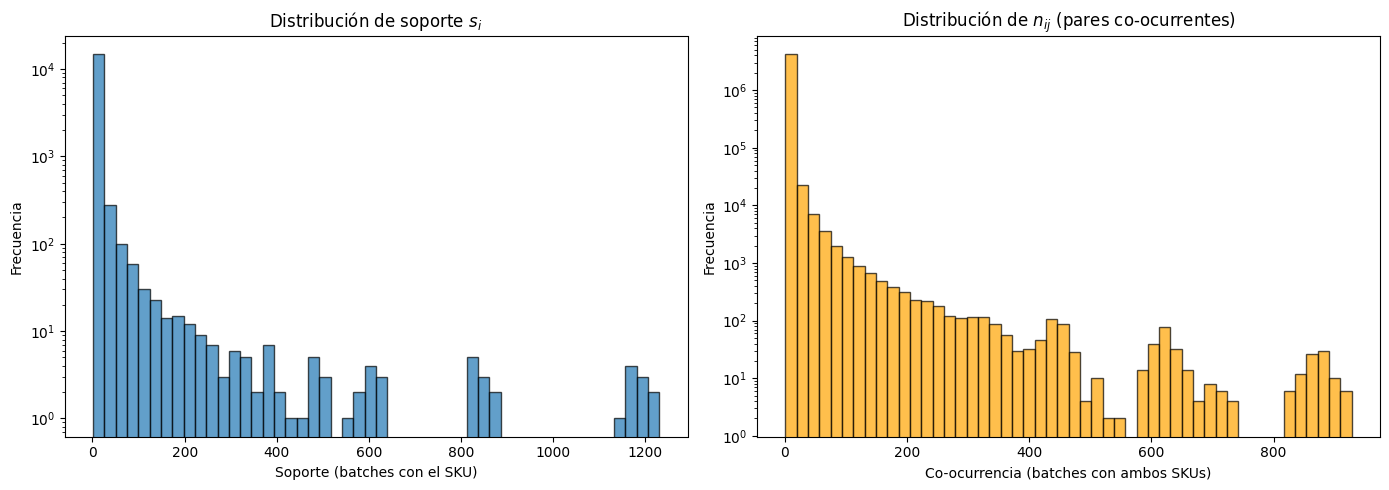

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución de soporte (batches por SKU)
axes[0].hist(co.support, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Soporte (batches con el SKU)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de soporte $s_i$')
axes[0].set_yscale('log')

# Distribución de co-ocurrencia (pares)
axes[1].hist(coo_nz, bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_xlabel('Co-ocurrencia (batches con ambos SKUs)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de $n_{ij}$ (pares co-ocurrentes)')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

## 4. Comparación de métricas: co-ocurrencia cruda vs Jaccard


Co-ocurrencia cruda (A_raw):
  nnz: 4,322,498
  min: 0.00, max: 928.00

Jaccard (A_jaccard):
  nnz: 4,322,498
  min: 0.000, max: 1.000


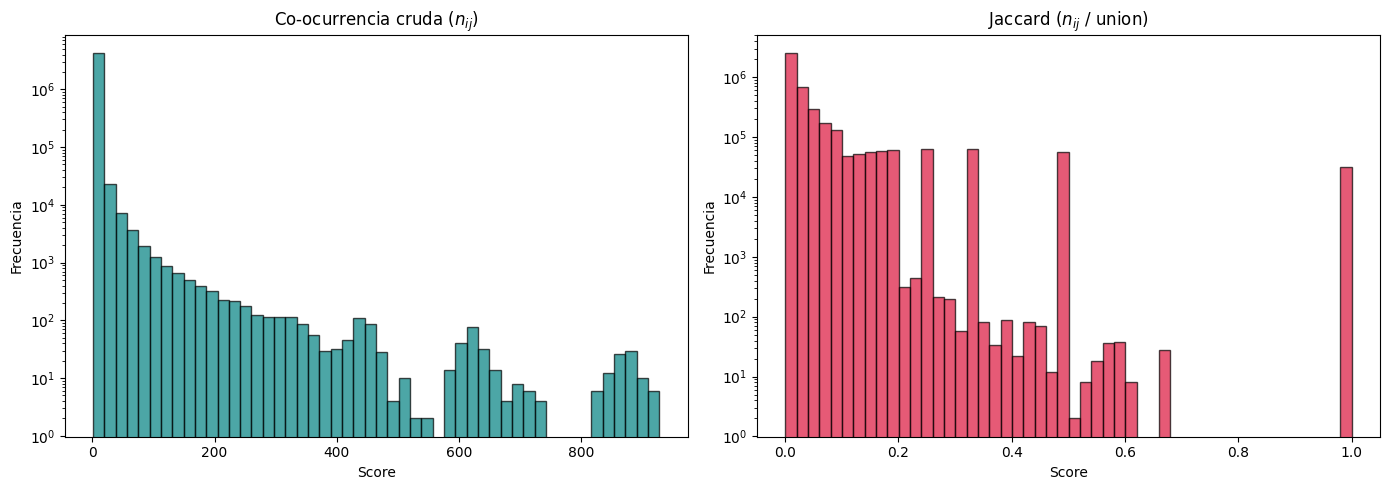

In [5]:
# Construir ambas métricas
raw_builder = affinity_registry.get('cooccurrence')()
jaccard_builder = affinity_registry.get('jaccard')()

A_raw = raw_builder.build(co.matrix, co.support, co.n_batches)
A_jaccard = jaccard_builder.build(co.matrix, co.support, co.n_batches)

print(f"Co-ocurrencia cruda (A_raw):")
print(f"  nnz: {A_raw.nnz:,}")
print(f"  min: {A_raw.min():.2f}, max: {A_raw.max():.2f}")
print(f"\nJaccard (A_jaccard):")
print(f"  nnz: {A_jaccard.nnz:,}")
print(f"  min: {A_jaccard.min():.3f}, max: {A_jaccard.max():.3f}")

# Distribuciones en la misma figura
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(A_raw.data, bins=50, edgecolor='black', alpha=0.7, color='teal')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Co-ocurrencia cruda ($n_{ij}$)')
axes[0].set_yscale('log')

axes[1].hist(A_jaccard.data, bins=50, edgecolor='black', alpha=0.7, color='crimson')
axes[1].set_xlabel('Score')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Jaccard ($n_{ij}$ / union)')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

## 5. Top pares más afines


In [6]:
# Top 20 pares por Jaccard
coo = A_jaccard.tocoo()
pairs_df = pd.DataFrame({
    'sku_i': co.skus[coo.row],
    'sku_j': co.skus[coo.col],
    'jaccard': coo.data
})
pairs_df = pairs_df.sort_values('jaccard', ascending=False)

print("Top 20 pares más afines (Jaccard):")
print(pairs_df.head(20).to_string(index=False))

Top 20 pares más afines (Jaccard):
    sku_i     sku_j  jaccard
SKU-00420 SKU-22401      1.0
SKU-00421 SKU-14706      1.0
SKU-12203 SKU-09094      1.0
SKU-12767 SKU-07234      1.0
SKU-12203 SKU-05117      1.0
SKU-00421 SKU-18058      1.0
SKU-15807 SKU-01602      1.0
SKU-25197 SKU-04210      1.0
SKU-12203 SKU-09915      1.0
SKU-24820 SKU-18572      1.0
SKU-04602 SKU-09713      1.0
SKU-04602 SKU-19703      1.0
SKU-12203 SKU-20436      1.0
SKU-04602 SKU-21933      1.0
SKU-12203 SKU-09895      1.0
SKU-17523 SKU-06399      1.0
SKU-12203 SKU-04394      1.0
SKU-10251 SKU-02607      1.0
SKU-12767 SKU-22801      1.0
SKU-04196 SKU-18444      1.0


## 6. Verificación de circularidad: ¿correlacionan batches con zonas del layout actual?

Hipótesis: Si los batches se arman por ventana temporal (independiente del layout actual),
no debería haber correlación entre la composición de un batch y la zona (bay) donde
están los SKUs actualmente. Si hay correlación fuerte, el slotting actual está
contaminando la señal de afinidad.


In [7]:
# Cargar el slotting actual: intenta preprocesada primero, fallback a raw
try:
    initial_stock = read_parquet(PROCESSED_DIR / 'initial_stock.parquet')
    print("Usando initial_stock preprocesada")
except FileNotFoundError:
    initial_stock = read_parquet(RAW_DIR / 'initial_stock.parquet')
    print("Usando initial_stock raw")

print(f"Initial stock: {len(initial_stock)} filas")
print(f"Columnas: {list(initial_stock.columns)}")
if initial_stock.empty:
    print("[warning]  Initial stock está vacío.")
else:
    print(initial_stock.head())

Usando initial_stock raw
Initial stock: 30000 filas
Columnas: ['location_id', 'location_name', 'bay_id', 'sku', 'merchant_account_id', 'units']
   location_id location_name  bay_id        sku merchant_account_id  units
0            1   A01-01-A-01  A01-01  SKU-00001             MER-001     12
1            2   A01-01-A-02  A01-01  SKU-00002             MER-010     19
2            3   A01-01-A-03  A01-01  SKU-00003             MER-001     10
3            4   A01-01-A-04  A01-01  SKU-00004             MER-009     16
4            5   A01-01-A-05  A01-01  SKU-00005             MER-007     43


Batches con mapping a bay: 1,600 / 1,600
Tamanio medio de batch (en SKUs): 76.3

Dispersin espacial (rango de bay indices por batch):
  Media: 979.4
  Mediana: 982.0
  Max: 999


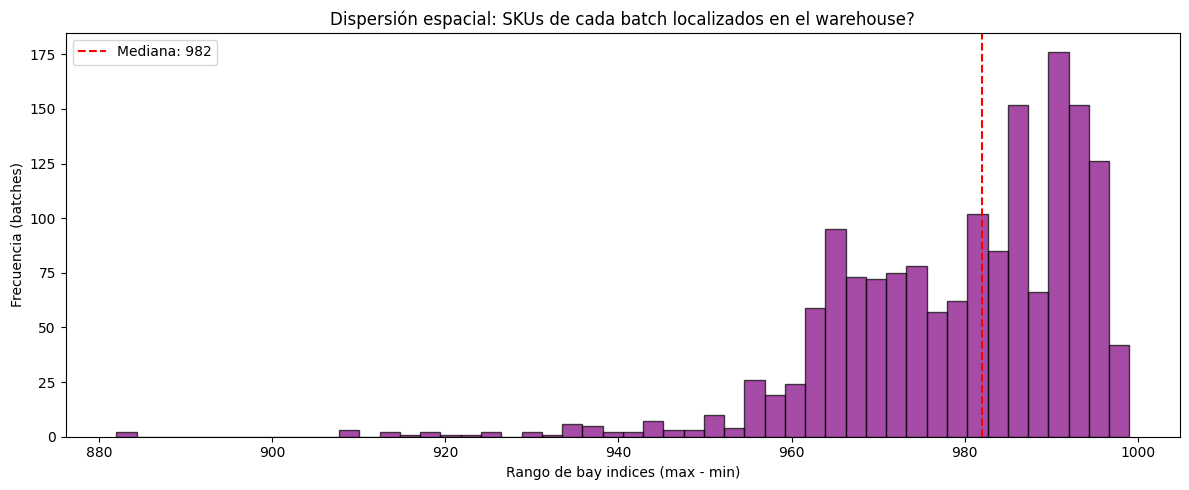

In [8]:
spatial_spread = []

if not initial_stock.empty and 'sku' in initial_stock.columns and 'bay_id' in initial_stock.columns:
    # Mapear SKU -> bay actual (primera ubicacion si hay duplicados)
    initial_stock_unique = initial_stock.drop_duplicates(subset=['sku'], keep='first')
    
    # Crear mapeo de bay_id string -> indice numerico
    unique_bays = sorted(initial_stock_unique['bay_id'].unique())
    bay_to_idx = {bay: i for i, bay in enumerate(unique_bays)}
    
    # Mapear SKU -> bay_idx numerico
    sku_to_bay_idx = {}
    for idx, row in initial_stock_unique.iterrows():
        sku_to_bay_idx[row['sku']] = bay_to_idx[row['bay_id']]

    # Para cada batch, extraer los bays donde están los SKUs actuales
    batch_bays = {}
    batch_sizes = {}

    for batch_id, group in picking_train.groupby('batch_id'):
        skus_in_batch = group['sku'].unique()
        bay_idxs_in_batch = [sku_to_bay_idx[sku] for sku in skus_in_batch if sku in sku_to_bay_idx]
        if bay_idxs_in_batch:
            batch_bays[batch_id] = bay_idxs_in_batch
            batch_sizes[batch_id] = len(bay_idxs_in_batch)

    print(f"Batches con mapping a bay: {len(batch_bays):,} / {picking_train['batch_id'].nunique():,}")
    if batch_sizes:
        print(f"Tamanio medio de batch (en SKUs): {np.mean(list(batch_sizes.values())):.1f}")

        # Métricas de dispersión espacial: ¿los SKUs de un batch están localizados?
        # Usamos el rango de bays como proxy
        for bay_idxs in batch_bays.values():
            if len(bay_idxs) > 1:
                spread = max(bay_idxs) - min(bay_idxs)
            else:
                spread = 0
            spatial_spread.append(spread)

        print(f"\nDispersin espacial (rango de bay indices por batch):")
        print(f"  Media: {np.mean(spatial_spread):.1f}")
        print(f"  Mediana: {np.median(spatial_spread):.1f}")
        print(f"  Max: {np.max(spatial_spread)}")

        fig, ax = plt.subplots(figsize=(12, 5))
        ax.hist(spatial_spread, bins=50, edgecolor='black', alpha=0.7, color='purple')
        ax.set_xlabel('Rango de bay indices (max - min)')
        ax.set_ylabel('Frecuencia (batches)')
        ax.set_title('Dispersión espacial: SKUs de cada batch localizados en el warehouse?')
        ax.axvline(np.median(spatial_spread), color='red', linestyle='--', 
                   label=f'Mediana: {np.median(spatial_spread):.0f}')
        ax.legend()
        plt.tight_layout()
        plt.show()
    else:
        print("[warning]  No hay batches con mapping exitoso a bay. Skipping dispersión espacial.")
else:
    if initial_stock.empty:
        print("[warning]  Initial stock esta vacio. Skipping analisis de circularidad.")
    else:
        print(f"[warning]  Columnas requeridas (sku, bay_id) no encontradas. Tengo: {list(initial_stock.columns)}")

In [9]:
if spatial_spread:
    # Interpretación
    if np.median(spatial_spread) < 500:  # Threshold arbitrario (ajustar según contexto)
        print("""
⚠️  ADVERTENCIA DE CIRCULARIDAD
    Los SKUs de cada batch tienden a estar localizados en pocas zonas (bays).
    Esto PODRÍA indicar que los batches se arman con sesgo por zona (wave picking).
    La afinidad captura parcialmente el layout actual, no solo la demanda independiente.
    Recomendación: usar Jaccard (normalizado) en lugar de co-ocurrencia cruda,
    y considerar métodos que no dependan de afinidad (ABC, etc.) como sanity-check.
        """)
    else:
        print("""
✅ INDICIO DE INDEPENDENCIA
    Los SKUs de cada batch están geográficamente dispersos en el warehouse.
    Esto es consistente con batches armados por ventana temporal, independientes del layout.
    La afinidad refleja patrones de demanda reales, no sesgada por el slotting vigente.
        """)
else:
    print("⚠️  No se pudo calcular dispersión espacial. Análisis de circularidad skipped.")


✅ INDICIO DE INDEPENDENCIA
    Los SKUs de cada batch están geográficamente dispersos en el warehouse.
    Esto es consistente con batches armados por ventana temporal, independientes del layout.
    La afinidad refleja patrones de demanda reales, no sesgada por el slotting vigente.
        


## 7. Resumen y conclusiones


RESUMEN DEL ANÁLISIS DE AFINIDADES
===================================

1. ESTRUCTURA DEL GRAFO SKU-SKU:
   - 15,554 SKUs, 1,600 batches
   - 4,322,498 pares co-ocurrentes (1.79% densidad)
   - Distribución: muy sesgada a la derecha (muchos pares débiles, pocos muy fuertes)

2. COMPARACIÓN DE MÉTRICAS:
   - Co-ocurrencia cruda: sin normalización, sesgada a SKUs frecuentes
   - Jaccard: normalizado por unión, en [0,1], penaliza individualmente frecuentes
   - Ambas preservan el patrón sparse

3. VERIFICACIÓN DE CIRCULARIDAD:
   - Dispersión espacial (rango de bays): 982.0
   - Interpretación: [ver celda anterior]

PRÓXIMO PASO:
   Usar Jaccard como métrica principal; comparar métodos sensibles a afinidad
   (two-stage, swaps) contra baselines insensibles (ABC) para medir el aporte real.